# 👗 Data Pipeline
**Fashion Compatibility Project | Deep Learning Course**

### What you'll do:
- Load the `Marqo/polyvore` dataset (94k items, 1 split called `'data'`)
- Extract outfit IDs from `item_ID` (e.g. `100002074_1` → outfit `100002074`)
- Build the `PolyvoreDataset` class with triplet sampling
- Create train/val DataLoaders ready for the model

---
⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU → Save`

## Cell 1 — Install dependencies

In [1]:
!pip install -q datasets torch torchvision Pillow numpy pandas matplotlib tqdm
print('✅ Done.')

✅ Done.


## Cell 2 — Load dataset and explore

In [2]:
from datasets import load_dataset

print('Loading Marqo/polyvore... (a few minutes the first time)')
dataset = load_dataset('Marqo/polyvore')

# The only split is called 'data'
print('\nAvailable splits:', list(dataset.keys()))  # ['data']
print('Total rows:', len(dataset['data']))

# Inspect one sample
sample = dataset['data'][0]
print('\nFields:', list(sample.keys()))
print('  category:', sample['category'])
print('  text:    ', sample['text'])
print('  item_ID: ', sample['item_ID'])   # e.g. '100002074_1'
print('  image:   ', type(sample['image']), sample['image'].size)

Loading Marqo/polyvore... (a few minutes the first time)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

data/data-00001-of-00006.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

...

data/data-00003-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00004-of-00006.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/data-00005-of-00006.parquet:   0%|          | 0.00/409M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/94096 [00:00<?, ? examples/s]


Available splits: ['data']
Total rows: 94096

Fields: ['image', 'category', 'text', 'item_ID']
  category: Day Dresses
  text:     tibi knit long sleeve dress
  item_ID:  100002074_1
  image:    <class 'PIL.JpegImagePlugin.JpegImageFile'> (274, 400)


## Cell 3 — Extract outfit IDs and explore outfit structure

In [3]:
import pandas as pd

# Build a DataFrame from non-image columns
df = pd.DataFrame({
    'category': dataset['data']['category'],
    'text':     dataset['data']['text'],
    'item_ID':  dataset['data']['item_ID'],
})

# Extract outfit ID from item_ID: '100002074_1' -> '100002074'
df['outfit_id'] = df['item_ID'].str.rsplit('_', n=1).str[0]

print('DataFrame shape:', df.shape)
print(df.head(10).to_string())

# Outfit statistics
outfit_sizes = df.groupby('outfit_id').size()
print(f'\nUnique outfits:       {df["outfit_id"].nunique()}')
print(f'Avg items per outfit: {outfit_sizes.mean():.1f}')
print(f'Min items per outfit: {outfit_sizes.min()}')
print(f'Max items per outfit: {outfit_sizes.max()}')
print(f'Outfits with ≥2 items: {(outfit_sizes >= 2).sum()}')

DataFrame shape: (94096, 4)
       category                                           text      item_ID  outfit_id
0   Day Dresses                    tibi knit long sleeve dress  100002074_1  100002074
1         Boots       michael kors leather over-the-knee boots  100002074_2  100002074
2      Handbags  givenchy leather medium antigona duffel black  100002074_3  100002074
3    Sunglasses      bottega veneta acetate leather sunglasses  100002074_4  100002074
4  Floral Decor                              pier imports stem  100002074_5  100002074
5         Coats                                   miranda coat  100002074_7  100002074
6       Blazers                            three pocket blazer  100010727_1  100010727
7  Skinny Jeans                           givenchy skinny jean  100010727_2  100010727
8       Watches      guess black silver-tone chronograph watch  100010727_4  100010727
9    Sunglasses           ray-ban original wayfarer sunglasses  100010727_5  100010727

Unique outfits

## Cell 4 — Visualize sample images

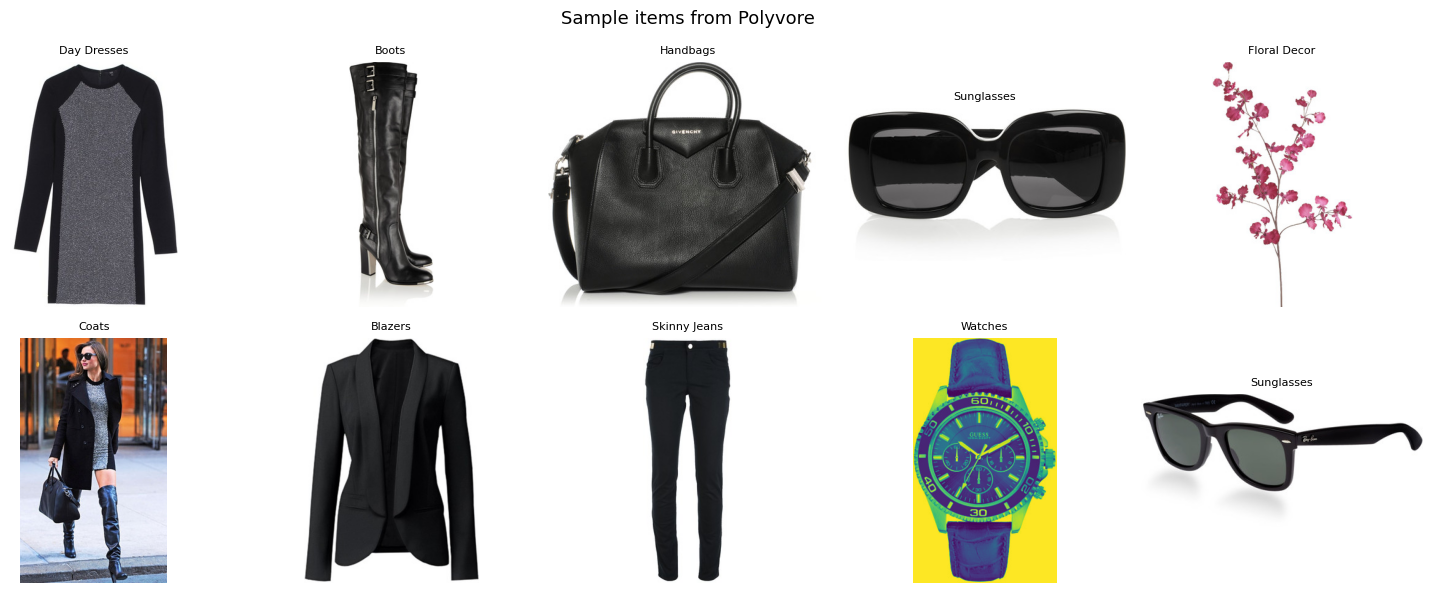

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample items from Polyvore', fontsize=13)
for i, ax in enumerate(axes.flat):
    s = dataset['data'][i]
    ax.imshow(s['image'])
    ax.set_title(s['category'][:20], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 5 — Visualize one complete outfit

Outfit ID: 100002074 — 6 items


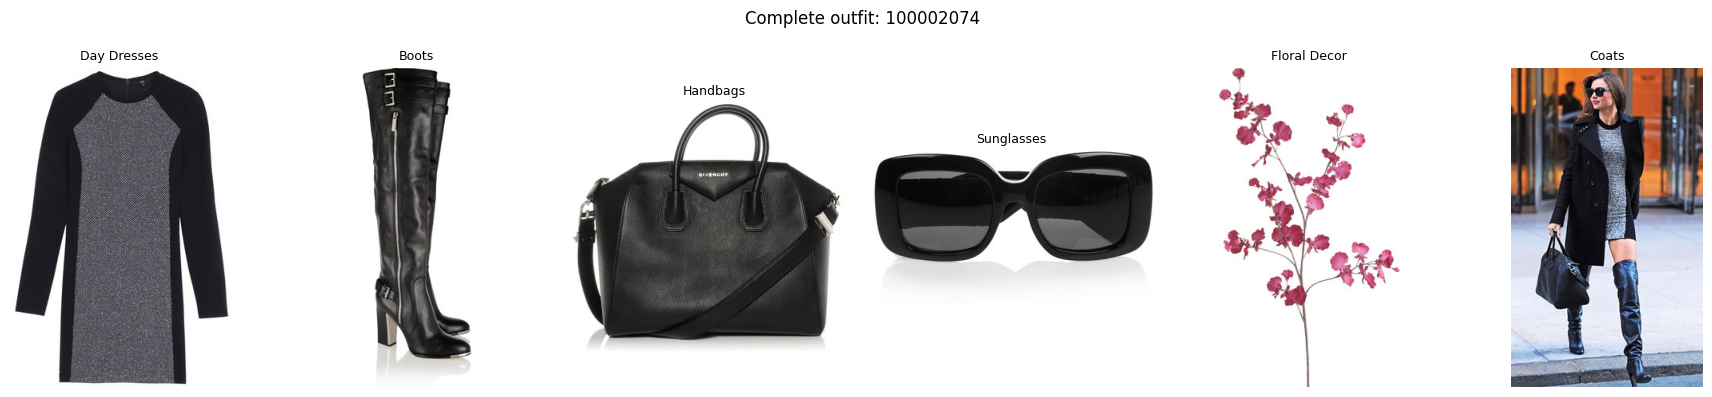

In [5]:
# Pick the first outfit with >= 3 items
valid = outfit_sizes[outfit_sizes >= 3]
first_outfit_id = valid.index[0]
outfit_rows = df[df['outfit_id'] == first_outfit_id]

print(f'Outfit ID: {first_outfit_id} — {len(outfit_rows)} items')

fig, axes = plt.subplots(1, len(outfit_rows), figsize=(3 * len(outfit_rows), 4))
if len(outfit_rows) == 1: axes = [axes]

for ax, (row_idx, row) in zip(axes, outfit_rows.iterrows()):
    img = dataset['data'][int(row_idx)]['image']
    ax.imshow(img)
    ax.set_title(row['category'][:15], fontsize=9)
    ax.axis('off')

plt.suptitle(f'Complete outfit: {first_outfit_id}', fontsize=12)
plt.tight_layout()
plt.show()

## Cell 6 — Train / Val split and transforms

In [6]:
from torchvision import transforms

# Split the data split 90% train / 10% val
all_data = dataset['data']
total    = len(all_data)
split_at = int(total * 0.9)

train_hf = all_data.select(range(0, split_at))
val_hf   = all_data.select(range(split_at, total))
print(f'Total: {total} | Train: {len(train_hf)} | Val: {len(val_hf)}')

# Training transform: augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Val/test transform: no augmentation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('✅ Transforms defined.')

Total: 94096 | Train: 84686 | Val: 9410
✅ Transforms defined.


## Cell 7 — PolyvoreDataset class with triplet sampling

In [7]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict


class PolyvoreDataset(Dataset):
    """
    Polyvore triplet dataset for metric learning.

    The dataset has one column 'item_ID' like '100002074_1'.
    The outfit ID is the prefix before the last underscore: '100002074'.
    Items sharing the same outfit ID are compatible.

    Each __getitem__ returns (anchor, positive, negative):
      - anchor & positive: two different items from the SAME outfit
      - negative:          one item from a DIFFERENT outfit
    """

    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform

        # Build outfit_id -> list of row indices
        self.outfit_to_idx = defaultdict(list)
        for i in range(len(hf_split)):
            item_id  = hf_split[i]['item_ID']           # e.g. '100002074_1'
            outfit_id = item_id.rsplit('_', 1)[0]       # e.g. '100002074'
            self.outfit_to_idx[outfit_id].append(i)

        # Only keep outfits with at least 2 items
        self.valid_outfits  = [o for o, idxs in self.outfit_to_idx.items() if len(idxs) >= 2]
        self.all_outfit_ids = list(self.outfit_to_idx.keys())

        print(f'  Items in split:        {len(hf_split)}')
        print(f'  Total outfits:         {len(self.all_outfit_ids)}')
        print(f'  Valid outfits (≥2):    {len(self.valid_outfits)}')

    def __len__(self):
        return len(self.valid_outfits)

    def _load(self, idx):
        img = self.data[idx]['image'].convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

    def __getitem__(self, idx):
        oid     = self.valid_outfits[idx]
        indices = self.outfit_to_idx[oid]

        # anchor + positive from SAME outfit
        a_idx, p_idx = random.sample(indices, 2)

        # negative from a DIFFERENT outfit
        neg_oid = random.choice([o for o in self.all_outfit_ids if o != oid])
        n_idx   = random.choice(self.outfit_to_idx[neg_oid])

        return self._load(a_idx), self._load(p_idx), self._load(n_idx)


print('✅ PolyvoreDataset class defined.')

✅ PolyvoreDataset class defined.


## Cell 8 — Build datasets and DataLoaders

In [8]:
BATCH_SIZE  = 64
NUM_WORKERS = 2

print('Building train dataset...')
train_dataset = PolyvoreDataset(train_hf, transform=train_transform)

print('\nBuilding val dataset...')
val_dataset = PolyvoreDataset(val_hf, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'\n✅ DataLoaders ready!')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches:   {len(val_loader)}')

Building train dataset...
  Items in split:        84686
  Total outfits:         19353
  Valid outfits (≥2):    18500

Building val dataset...
  Items in split:        9410
  Total outfits:         2235
  Valid outfits (≥2):    2115

✅ DataLoaders ready!
   Train batches: 290
   Val batches:   34


## Cell 9 — Sanity check: load and visualize one triplet

Batch shapes:
  Anchor:   torch.Size([64, 3, 224, 224])
  Positive: torch.Size([64, 3, 224, 224])
  Negative: torch.Size([64, 3, 224, 224])


/tmp/ipykernel_1523/2791976561.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1523/2791976561.py:23: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


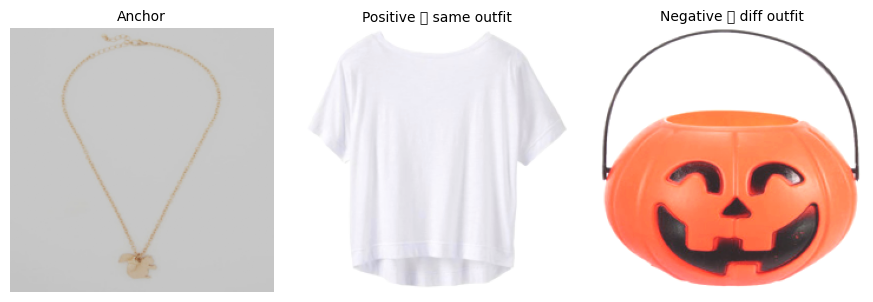


✅ Data pipeline works!


In [9]:
import numpy as np

anchor, positive, negative = next(iter(train_loader))

print('Batch shapes:')
print(f'  Anchor:   {anchor.shape}')    # [64, 3, 224, 224]
print(f'  Positive: {positive.shape}')
print(f'  Negative: {negative.shape}')

# Denormalize for display
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, title in zip(axes,
    [anchor[0], positive[0], negative[0]],
    ['Anchor', 'Positive ✅ same outfit', 'Negative ❌ diff outfit']):
    ax.imshow(denorm(img))
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

print('\n✅ Data pipeline works!')

## Cell 10 — Summary

In [10]:
print('=' * 48)
print('  DATA PIPELINE SUMMARY')
print('=' * 48)
print(f'  Dataset split used:   "data" (only split)')
print(f'  Outfit ID extraction: item_ID.rsplit("_",1)[0]')
print(f'  Train items:          {len(train_hf)}')
print(f'  Val items:            {len(val_hf)}')
print(f'  Train triplets:       {len(train_dataset)}')
print(f'  Val triplets:         {len(val_dataset)}')
print(f'  Batch size:           {BATCH_SIZE}')
print(f'  Train batches/epoch:  {len(train_loader)}')
print(f'  Image tensor shape:   [B, 3, 224, 224]')
print(f'  Each batch returns:   (anchor, positive, negative)')
print(f'  Normalized with:      ImageNet mean/std')
print('=' * 48)

  DATA PIPELINE SUMMARY
  Dataset split used:   "data" (only split)
  Outfit ID extraction: item_ID.rsplit("_",1)[0]
  Train items:          84686
  Val items:            9410
  Train triplets:       18500
  Val triplets:         2115
  Batch size:           64
  Train batches/epoch:  290
  Image tensor shape:   [B, 3, 224, 224]
  Each batch returns:   (anchor, positive, negative)
  Normalized with:      ImageNet mean/std
